<a href="https://colab.research.google.com/github/Mitali-Kambli20/CSL701-CE13_Machine-Learning-Lab/blob/main/ML_EXP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning Experiment Number 3

Name : Mitali Manohar Kambli

Roll No:CE13

Aim : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.

Learning Outcomes • Understand the working principle of Multiple Linear Regression.

• Perform data preprocessing and feature engineering.

• Convert categorical data into numerical features.

• Standardize numerical features.

• Implement the Ordinary Least Squares method using matrix operations.

• Train and test a regression model without using a ready-made regression function.

• Evaluate and interpret regression performance using RSS and R².

• Understand the effect of individual features on the predicted price.

### Dataset

Use the CarDekho Used Car Dataset (car data.csv). CarDekho Used Car Dataset

Explain meaning of each attribute in this dataset in below comment section :

Here, Selling_Price is the target variable.

# Software/Tools Required

•Python 3.x

•Google Colab / Jupyter Notebook

•NumPy

•Matplotlib

Task 1: Set Up the Python Environment**

•Create a new Google Colab notebook.

•Import NumPy for numerical and matrix operations.

•Import Matplotlib for data visualization.

•Do not use ready-made machine-learning regression functions such as LinearRegression() from Scikit-learn.

•The regression model must be implemented using matrix operations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd





## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Task 2: Upload the dataset from your computer

from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

# Load the uploaded CSV file

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")

# Display first five records

df.head()

# Find dataset dimensions

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

# Display all column names

print("Column names:")
for column in df.columns:
    print(column)

# Identify numerical and categorical attributes

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical attributes:")
print(numerical_columns)

print("\nCategorical attributes:")
print(categorical_columns)

# Identify numerical and categorical attributes

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical attributes:")
print(numerical_columns)

print("\nCategorical attributes:")
print(categorical_columns)

# Display information about the dataset

df.info()


# Separate target variable

y_original = df["selling_price"]

print("Target variable: selling_price")
print("Target shape:", y_original.shape)

# Display basic statistical information

df.describe()

Saving cardekho_dataset.csv to cardekho_dataset (2).csv
Uploaded file: cardekho_dataset (2).csv
Dataset loaded successfully!
Number of rows: 15411
Number of columns: 14
Column names:
Unnamed: 0
car_name
brand
model
vehicle_age
km_driven
seller_type
fuel_type
transmission_type
mileage
engine
max_power
seats
selling_price
Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed:

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

# Calculate total number of missing values

total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

# Handle missing values

if total_missing > 0:
    print("Missing values found.")
    print("Removing rows containing missing values...")

    df = df.dropna().reset_index(drop=True)

    print("Missing values removed.")
else:
    print("No missing values found. No rows were removed.")

# Verify that no missing values remain

print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nTotal missing values after preprocessing:",
      df.isnull().sum().sum())

# Display final dataset dimensions

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])



Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64
Total missing values: 0
No missing values found. No rows were removed.
Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values after preprocessing: 0
Final number of rows: 15411
Final number of columns: 14


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Task 4: Examine available attributes

print("Available attributes:")
print(df.columns.tolist())

# Select meaningful predictor variables

selected_features = [
    "km_driven",
    "fuel_type",
    "seller_type",
    "transmission_type",
    "vehicle_age", # Replaced 'Year' with 'vehicle_age'
    "mileage",
    "engine",
    "max_power",
    "seats"
]

print("Selected predictor variables:")
for feature in selected_features:
    print("-", feature)

# Create a separate dataframe for the regression experiment

df_model = df[selected_features + ["selling_price"]].copy()

print("Working dataset created.")
print("Shape:", df_model.shape)

df_model.head()

Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Selected predictor variables:
- km_driven
- fuel_type
- seller_type
- transmission_type
- vehicle_age
- mileage
- engine
- max_power
- seats
Working dataset created.
Shape: (15411, 10)


,km_driven,fuel_type,seller_type,transmission_type,vehicle_age,mileage,engine,max_power,seats,selling_price
0,120000,Petrol,Individual,Manual,9,19.70,796,46.30,5,120000
1,20000,Petrol,Individual,Manual,5,18.90,1197,82.00,5,550000
2,60000,Petrol,Individual,Manual,11,17.00,1197,80.00,5,215000
3,37000,Petrol,Individual,Manual,9,20.92,998,67.10,5,226000
4,30000,Diesel,Dealer,Manual,6,22.77,1498,98.59,5,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: Display categories
print("Fuel types:")
print(df_model["fuel_type"].unique())

print("\nSeller types:")
print(df_model["seller_type"].unique())

print("\nTransmission types:")
print(df_model["transmission_type"].unique())

# Convert categorical variables into dummy variables

df_encoded = pd.get_dummies(
    df_model,
    columns=["fuel_type", "seller_type", "transmission_type"],
    drop_first=True,
    dtype=float
)

print("Dataset after categorical encoding:")
display(df_encoded.head())

# Display all columns after encoding

print("Columns after encoding:")

for column in df_encoded.columns:
    print(column)

# Verify that all predictors are numerical

print(df_encoded.dtypes)

# Check whether every column is numerical

all_numeric = all(
    np.issubdtype(dtype, np.number)
    for dtype in df_encoded.dtypes
)

print("Are all columns numerical?", all_numeric)

Fuel types:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

Seller types:
['Individual' 'Dealer' 'Trustmark Dealer']

Transmission types:
['Manual' 'Automatic']
Dataset after categorical encoding:


,km_driven,vehicle_age,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,120000,9,19.70,796,46.30,5,120000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,20000,5,18.90,1197,82.00,5,550000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,60000,11,17.00,1197,80.00,5,215000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,37000,9,20.92,998,67.10,5,226000,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,30000,6,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,0.0,0.0,1.0


Columns after encoding:
km_driven
vehicle_age
mileage
engine
max_power
seats
selling_price
fuel_type_Diesel
fuel_type_Electric
fuel_type_LPG
fuel_type_Petrol
seller_type_Individual
seller_type_Trustmark Dealer
transmission_type_Manual
km_driven                         int64
vehicle_age                       int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_type_Manual        float64
dtype: object
Are all columns numerical? True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Feature Engineering

CURRENT_YEAR = 2026

# Create Car_Age (using vehicle_age as it already represents age)

df_encoded["Car_Age"] = df_encoded["vehicle_age"]

# Display vehicle_age and Car_Age

display(
    df_encoded[["vehicle_age", "Car_Age"]].head(10)
)

# Check whether car ages are reasonable

print("Minimum car age:", df_encoded["Car_Age"].min())
print("Maximum car age:", df_encoded["Car_Age"].max())
# Remove original vehicle_age column as Car_Age is now created from it

df_encoded.drop(columns=["vehicle_age"], inplace=True)

print("vehicle_age column removed.")
print("Remaining columns:")
print(df_encoded.columns.tolist())

# Display the newly created feature

display(df_encoded[["Car_Age"]].head(10))

,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4


Minimum car age: 0
Maximum car age: 29
vehicle_age column removed.
Remaining columns:
['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual', 'Car_Age']


,Car_Age
0,9
1,5
2,11
3,9
4,6
5,8
6,8
7,3
8,2
9,4


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

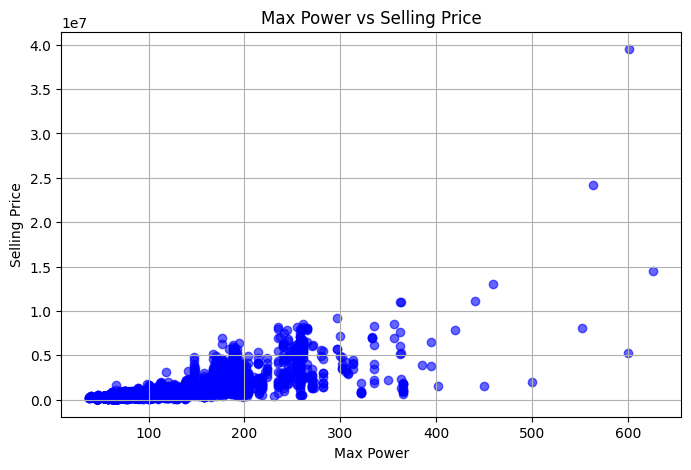

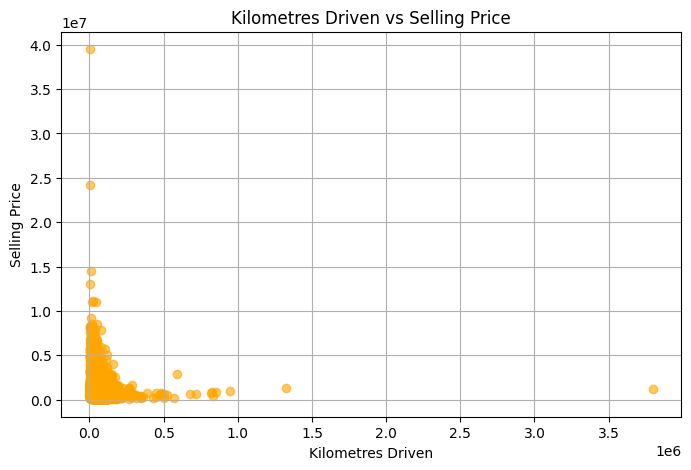

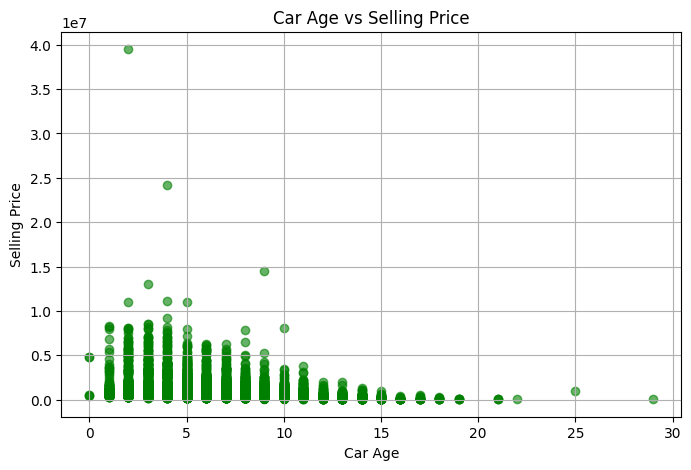

In [ ]:
# Task 7: Scatter plot of max_power vs selling_price

plt.figure(figsize=(8, 5))

plt.scatter(
    df_encoded["max_power"],
    df_encoded["selling_price"],
    color="blue",
    alpha=0.6
)

plt.xlabel("Max Power")
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price")

plt.grid(True)
plt.show()

# Scatter plot of km_driven vs selling_price

plt.figure(figsize=(8, 5))

plt.scatter(
    df_encoded["km_driven"],
    df_encoded["selling_price"],
    color="orange",
    alpha=0.6
)

plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.title("Kilometres Driven vs Selling Price")

plt.grid(True)
plt.show()


# Scatter plot of Car_Age vs Selling_Price

plt.figure(figsize=(8, 5))

plt.scatter(
    df_encoded["Car_Age"],
    df_encoded["selling_price"],
    color="green",
    alpha=0.6
)

plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")

plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Task 8: Separate predictors and target

X_df = df_encoded.drop(columns=["selling_price"])
y = df_encoded["selling_price"].to_numpy().reshape(-1, 1)

print("Predictor columns:")
print(X_df.columns.tolist())

print("\nX shape:", X_df.shape)
print("y shape:", y.shape)


# Convert predictor dataframe to NumPy array

X = X_df.to_numpy(dtype=float)

print("X data type:", X.dtype)
print("X shape:", X.shape)

# Random 80:20 train-test split

np.random.seed(42)

n = len(X)

indices = np.random.permutation(n)

train_size = int(0.8 * n)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

Xtrain = X[train_indices]
Xtest = X[test_indices]

ytrain = y[train_indices]
ytest = y[test_indices]

print("Training observations:", Xtrain.shape[0])
print("Testing observations:", Xtest.shape[0])

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)


Predictor columns:
['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual', 'Car_Age']

X shape: (15411, 13)
y shape: (15411, 1)
X data type: float64
X shape: (15411, 13)
Training observations: 12328
Testing observations: 3083
Xtrain shape: (12328, 13)
ytrain shape: (12328, 1)
Xtest shape: (3083, 13)
ytest shape: (3083, 1)


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Identify numerical predictors

feature_names = X_df.columns.tolist()

print("Feature names with indices:")

for index, feature in enumerate(feature_names):
    print(index, "->", feature)

numerical_features = [
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "Car_Age"
]

print("\nFeatures to standardize:")
for feature in numerical_features:
    print("-", feature)

# Find column indices of numerical features

numerical_indices = [
    feature_names.index(feature)
    for feature in numerical_features
]

print("Numerical feature indices:", numerical_indices)


Feature names with indices:
0 -> km_driven
1 -> mileage
2 -> engine
3 -> max_power
4 -> seats
5 -> fuel_type_Diesel
6 -> fuel_type_Electric
7 -> fuel_type_LPG
8 -> fuel_type_Petrol
9 -> seller_type_Individual
10 -> seller_type_Trustmark Dealer
11 -> transmission_type_Manual
12 -> Car_Age

Features to standardize:
- km_driven
- mileage
- engine
- max_power
- seats
- Car_Age
Numerical feature indices: [0, 1, 2, 3, 4, 12]


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Calculate mean using training data ONLY

train_mean = Xtrain[:, numerical_indices].mean(axis=0)

print("Training means:")
for feature, mean in zip(numerical_features, train_mean):
    print(f"{feature}: {mean:.4f}")

# Calculate standard deviation using training data ONLY

train_std = Xtrain[:, numerical_indices].std(axis=0)

print("Training standard deviations:")
for feature, std in zip(numerical_features, train_std):
    print(f"{feature}: {std:.4f}")

# Prevent division by zero

train_std[train_std == 0] = 1

# Standardize training numerical features

Xtrain_scaled = Xtrain.copy()

Xtrain_scaled[:, numerical_indices] = (
    Xtrain[:, numerical_indices] - train_mean
) / train_std

# Standardize test data using TRAINING statistics

Xtest_scaled = Xtest.copy()

Xtest_scaled[:, numerical_indices] = (
    Xtest[:, numerical_indices] - train_mean
) / train_std

# Check mean and standard deviation of standardized training features

print("Mean after standardization:")

for i, feature in enumerate(numerical_features):
    print(
        f"{feature}: "
        f"{Xtrain_scaled[:, numerical_indices[i]].mean():.6f}"
    )

print("\nStandard deviation after standardization:")

for i, feature in enumerate(numerical_features):
    print(
        f"{feature}: "
        f"{Xtrain_scaled[:, numerical_indices[i]].std():.6f}"
    )


Training means:
km_driven: 55692.8196
mileage: 19.6916
engine: 1485.0374
max_power: 100.5167
seats: 5.3262
Car_Age: 6.0324
Training standard deviations:
km_driven: 54470.9544
mileage: 4.1726
engine: 518.2760
max_power: 42.7440
seats: 0.8096
Car_Age: 3.0187
Mean after standardization:
km_driven: 0.000000
mileage: -0.000000
engine: 0.000000
max_power: 0.000000
seats: -0.000000
Car_Age: 0.000000

Standard deviation after standardization:
km_driven: 1.000000
mileage: 1.000000
engine: 1.000000
max_power: 1.000000
seats: 1.000000
Car_Age: 1.000000


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Construct feature matrices

print("Xtrain:")
print("Rows:", Xtrain_scaled.shape[0])
print("Columns:", Xtrain_scaled.shape[1])

print("\nytrain:")
print("Rows:", ytrain.shape[0])
print("Columns:", ytrain.shape[1])

print("\nXtest:")
print("Rows:", Xtest_scaled.shape[0])
print("Columns:", Xtest_scaled.shape[1])

print("\nytest:")
print("Rows:", ytest.shape[0])
print("Columns:", ytest.shape[1])


Xtrain:
Rows: 12328
Columns: 13

ytrain:
Rows: 12328
Columns: 1

Xtest:
Rows: 3083
Columns: 13

ytest:
Rows: 3083
Columns: 1


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 12: Add bias/intercept column

Xtrain_bias = np.column_stack([
    np.ones(Xtrain_scaled.shape[0]),
    Xtrain_scaled
])

Xtest_bias = np.column_stack([
    np.ones(Xtest_scaled.shape[0]),
    Xtest_scaled
])

print("Xtrain with bias:", Xtrain_bias.shape)
print("Xtest with bias:", Xtest_bias.shape)

print("First 5 rows of Xtrain with bias:")

print(Xtrain_bias[:5])



Xtrain with bias: (12328, 14)
Xtest with bias: (3083, 14)
First 5 rows of Xtrain with bias:
[[ 1.00000000e+00  3.17732278e-01  1.60198190e-01 -5.55760666e-01
  -5.05726422e-01 -4.02990451e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  1.97683120e+00]
 [ 1.00000000e+00  4.23561590e-02  1.84498573e+00 -4.57357492e-01
  -6.20362516e-01 -4.02990451e-01  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   1.00000000e+00 -6.73274828e-01]
 [ 1.00000000e+00  7.39975660e-01  2.58457492e-01 -4.57357492e-01
  -2.75050527e-01  2.06745524e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  3.20514932e-01]
 [ 1.00000000e+00 -9.39818665e-01 -3.09529203e-01  2.50110103e-02
   4.40606231e-01 -4.02990451e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.000000

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Task 13: Ordinary Least Squares function

def ols_fit(X, y):
    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate beta using normal equation
    beta = np.linalg.inv(XTX) @ XTy

    return beta

# Train the OLS model

beta = ols_fit(Xtrain_bias, ytrain)

print("OLS model trained successfully.")

print("Regression coefficient vector:")
print(beta)



OLS model trained successfully.
Regression coefficient vector:
[[ 994217.80724363]
 [ -34965.02601204]
 [  62397.2943623 ]
 [  48021.8182965 ]
 [ 644333.49945541]
 [   6812.17431665]
 [-124692.4295625 ]
 [ -96756.41053173]
 [ 358735.63796484]
 [-119859.21560938]
 [  -6783.55536347]
 [ -78002.67281776]
 [-121450.23037614]
 [-195163.09053546]]


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Check matrix singularity

XTX = Xtrain_bias.T @ Xtrain_bias

print("Shape of X^T X:", XTX.shape)

det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

if np.isclose(det_XTX, 0):
    print("X^T X is singular or nearly singular.")
else:
    print("X^T X is not singular.")

condition_number = np.linalg.cond(XTX)

print("Condition number:", condition_number)


Shape of X^T X: (14, 14)
Determinant of X^T X:
4.028687647671399e+43
X^T X is not singular.
Condition number: 11706.366913708209


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Associate coefficients with features

coefficient_names = ["Intercept"] + feature_names

print("Regression coefficients:\n")

for name, coefficient in zip(
    coefficient_names,
    beta.flatten()
):
    print(f"{name:25s} : {coefficient:.6f}")


Regression coefficients:

Intercept                 : 994217.807244
km_driven                 : -34965.026012
mileage                   : 62397.294362
engine                    : 48021.818296
max_power                 : 644333.499455
seats                     : 6812.174317
fuel_type_Diesel          : -124692.429563
fuel_type_Electric        : -96756.410532
fuel_type_LPG             : 358735.637965
fuel_type_Petrol          : -119859.215609
seller_type_Individual    : -6783.555363
seller_type_Trustmark Dealer : -78002.672818
transmission_type_Manual  : -121450.230376
Car_Age                   : -195163.090535


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Interpret coefficient signs

print("Coefficient interpretation:\n")

for name, coefficient in zip(
    coefficient_names,
    beta.flatten()
):

    if coefficient > 0:
        direction = "Positive"
    elif coefficient < 0:
        direction = "Negative"
    else:
        direction = "Zero"

    print(
        f"{name:25s} : "
        f"{coefficient:10.6f} "
        f"({direction})"
    )

# Compare magnitude of predictor coefficients

predictor_coefficients = beta.flatten()[1:]

coefficient_importance = np.abs(predictor_coefficients)

sorted_features = sorted(
    zip(feature_names, coefficient_importance),
    key=lambda x: x[1],
    reverse=True
)

print("Features ranked by absolute coefficient:\n")

for feature, importance in sorted_features:
    print(f"{feature:25s} : {importance:.6f}")



Coefficient interpretation:

Intercept                 : 994217.807244 (Positive)
km_driven                 : -34965.026012 (Negative)
mileage                   : 62397.294362 (Positive)
engine                    : 48021.818296 (Positive)
max_power                 : 644333.499455 (Positive)
seats                     : 6812.174317 (Positive)
fuel_type_Diesel          : -124692.429563 (Negative)
fuel_type_Electric        : -96756.410532 (Negative)
fuel_type_LPG             : 358735.637965 (Positive)
fuel_type_Petrol          : -119859.215609 (Negative)
seller_type_Individual    : -6783.555363 (Negative)
seller_type_Trustmark Dealer : -78002.672818 (Negative)
transmission_type_Manual  : -121450.230376 (Negative)
Car_Age                   : -195163.090535 (Negative)
Features ranked by absolute coefficient:

max_power                 : 644333.499455
fuel_type_LPG             : 358735.637965
Car_Age                   : 195163.090535
fuel_type_Diesel          : 124692.429563
transmission_type

## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Task 17: Predict test-set selling prices

y_pred = Xtest_bias @ beta

print("Predictions generated successfully.")
print("Prediction shape:", y_pred.shape)

# Display first 10 actual and predicted values

print("Actual Price     Predicted Price")
print("-" * 40)

for actual, predicted in zip(
    ytest[:10].flatten(),
    y_pred[:10].flatten()
):
    print(f"{actual:12.2f}     {predicted:12.2f}")




Predictions generated successfully.
Prediction shape: (3083, 1)
Actual Price     Predicted Price
----------------------------------------
  4450000.00       2046440.49
  1290000.00       1431417.81
   485000.00        339097.18
   400000.00        543268.20
   800000.00        862352.98
   150000.00       -616511.22
   650000.00        820935.00
   325000.00       -175814.55
   300000.00        378640.92
   925000.00        776919.73
First 10 residuals:
[2403559.51403373 -141417.81281598  145902.81901473 -143268.19891449
  -62352.98172047  766511.2216015  -170934.99714304  500814.55130593
  -78640.91740411  148080.26893045]
Residual Sum of Squares (RSS):
885105657669987.0


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Task 18: Calculate prediction errors

residuals = ytest - y_pred

print("First 10 residuals:")
print(residuals[:10].flatten())

# Calculate Residual Sum of Squares

RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)


First 10 residuals:
[2403559.51403373 -141417.81281598  145902.81901473 -143268.19891449
  -62352.98172047  766511.2216015  -170934.99714304  500814.55130593
  -78640.91740411  148080.26893045]
Residual Sum of Squares (RSS):
885105657669987.0


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


In [ ]:
# Task 19: Calculate Total Sum of Squares

ytest_mean = np.mean(ytest)

TSS = np.sum(
    (ytest - ytest_mean) ** 2
)

print("Total Sum of Squares (TSS):")
print(TSS)

# Calculate R-squared

R2 = 1 - (RSS / TSS)

print("R² =", R2)

print(f"R² percentage = {R2 * 100:.2f}%")


Total Sum of Squares (TSS):
2407385049859876.5
R² = 0.6323373123375069
R² percentage = 63.23%


### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction
